## HIT140 - WC2026. Did players on teams that advanced past the group stage show a bigger gap in penetrative passing (linebreaks) or safe passing (accuracy) compared to players on teams eliminated in the group stage?
Most people judge a team by pass completion rate. How many passed find a teammate. But a safe pase isn't the same as dangerous one: a team can complete 95% of its passes while barely being on a opposition side, if none of these passes actually break through the defensive line. So lets see if this myth is true. I separate players into two groups based on tournament outcome. Those on teams that advanced past the group stage (32 teams) versus those eliminated in the group stage (16 teams). This isn't a clean split. Group draws are seeded, not random so 'advanced' reflects group difficulty, not just team quality.I group teams by advancement past the group stage rather than by reaching the Round of 16, since a single knockout result can hinge on one moment
rather than reflecting overall team quality.

## Data Collection

I initially reverse-engineereed FIFA's authenticated internal API (via DevTools network inspection, extracting the bearer token used by official site) to scrape players stats directly. This scraped most of the stats we wanted, but still had some gap. We thought for going for Fbref which introduced cross-source name-matching problem.
We later identified the FIFA also exposes unauthenticated public endpoints serving the same data with all the stats we wanted, which eliminated the need of joining the data from two sources.
Before solely adapting this data source, lets validate against our old scraper which directly scraped from official website's endpoints.

In [160]:
# Data scraped from old scraper
import pandas as pd
dist = pd.read_csv("wc026_distribution.csv")
print(dist.shape)
print(dist.columns.tolist())

(1813, 14)
['name', 'shirt', 'team', 'passes', 'passes_completed', 'passing_accuracy_rate', 'crosses', 'crossing_accuracy_rate', 'take_ons_completed', 'linebreaks_attempted_defensive_line', 'linebreak_attempted_defensive_line_rate', 'attempted_switches_of_play', 'switches_of_play_rate', 'position']


In [161]:
import requests
import time

headers = {"User-Agent": "Mozilla/5.0"}
r = requests.get("https://api.fifa.com/api/v3/teamsqualified/season/285023",
                  params={"language": "en", "count": 100}, headers=headers)
teams_data = r.json()
code_to_id = {t["IdCountry"]: t["IdTeam"] for t in teams_data["Results"]}

name_to_id = {}
for code, team_id in code_to_id.items():
    r = requests.get(f"https://api.fifa.com/api/v3/teams/{team_id}/squad",
                      params={"idCompetition": 17, "idSeason": 285023, "language": "en"},
                      headers=headers)
    squad = r.json()
    for p in squad["Players"]:
        pname = p["PlayerName"][0]["Description"].upper()
        name_to_id[(code, pname)] = p["IdPlayer"]
    time.sleep(0.1)

print(len(code_to_id), len(name_to_id))

48 1248


The API has a id rather than explicit names, we have stored team code and player's code to compare.

In [162]:
# Pulling player's data
r = requests.get("https://fdh-api.fifa.com/v1/stats/season/285023/players.json", headers=headers)
players_data = r.json()
print(len(players_data))

1259


In [163]:
import random

dist_played = dist[dist['passes']>0].copy()
random.seed(42)
sample = dist_played.sample(15, random_state=42)

matched, unmatched = [], []
for _, row in sample.iterrows():
    key = (row["team"], row["name"].upper())
    if key in name_to_id:
        pid = name_to_id[key]
        api_stats = {f[0]: f[1] for f in players_data[pid]}
        if api_stats.get("TimePlayed", 0) > 0:
            matched.append((row, pid))
        else:
            unmatched.append((row["name"], "0 minutes played"))
    else:
        unmatched.append((row["name"], "no name match"))

print(f"matched: {len(matched)} / 15")
print("unmatched:", unmatched)

matched: 14 / 15
unmatched: [('Brandon Thomas Asante', 'no name match')]


Before assuming every name would match cleanly, I tested again a raw random sample and found out why it didnt match. Lets see why it didn't match.

In [164]:
row = sample[sample["name"] == "Brandon Thomas Asante"].iloc[0]
team_code = row["team"]

for k in name_to_id:
    if k[0] == team_code and "ASANTE" in k[1]:
        print(k[1])

BRANDON THOMAS-ASANTE


Be assured cause its the hyphens.

In [165]:
results = []
for row, pid in matched:
    api_stats = {f[0]: f[1] for f in players_data[pid]}
    results.append({
        "name": row["name"],
        "old_passes": row["passes"], "new_passes": api_stats.get("Passes"),
        "old_completed": row["passes_completed"], "new_completed": api_stats.get("PassesCompleted"),
        "old_linebreaks": row["linebreaks_attempted_defensive_line"], "new_linebreaks": api_stats.get("LinebreaksAttemptedDefensiveLine"),
    })

comparison = pd.DataFrame(results)
print(comparison)

                   name  old_passes  new_passes  old_completed  new_completed  \
0          Leo Ostigard        99.0          99           84.0             84   
1          Kenny Mclean        63.0          63           56.0             56   
2          Lionel Messi       367.0         367          288.0            288   
3      Deveron Fonville        66.0          66           55.0             55   
4             Tim Payne        87.0          87           72.0             72   
5          Amir Murillo       112.0         112           88.0             88   
6         Sondre Langas        10.0          10            9.0              9   
7   Amir Hadziahmetovic         3.0           3            3.0              3   
8      Evidence Makgopa        29.0          29           20.0             20   
9          Raul Jimenez        66.0          66           48.0             48   
10  Christian Fassnacht         5.0           5            5.0              5   
11       Iqraam Rayners     

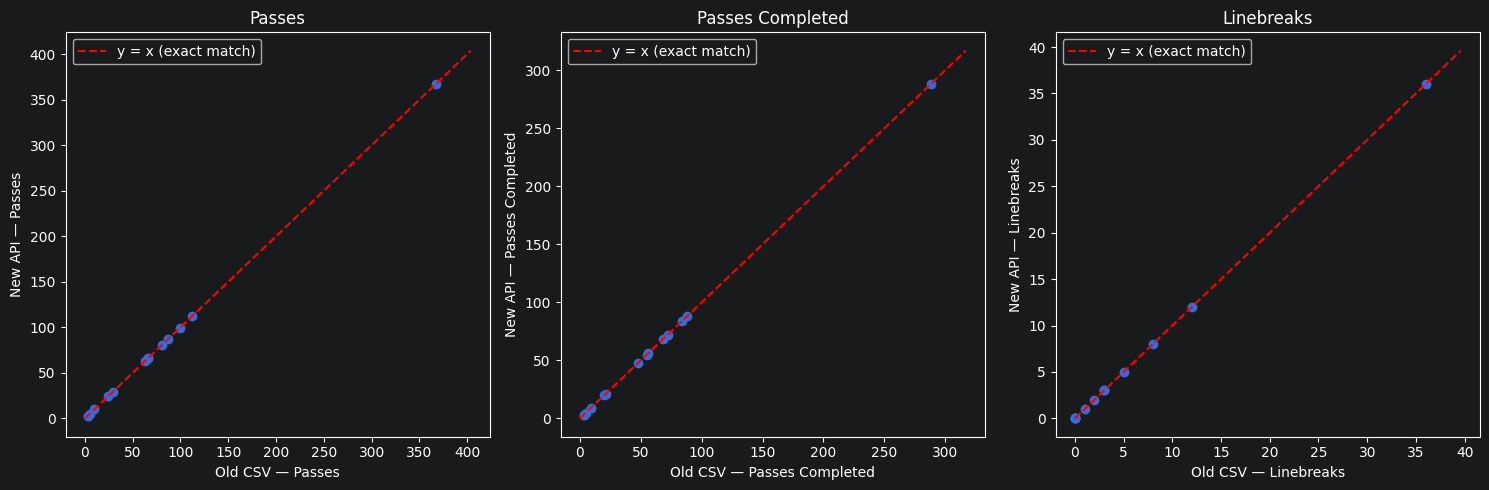

In [166]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (old_col, new_col, label) in zip(axes, [
    ("old_passes", "new_passes", "Passes"),
    ("old_completed", "new_completed", "Passes Completed"),
    ("old_linebreaks", "new_linebreaks", "Linebreaks"),
]):
    ax.scatter(comparison[old_col], comparison[new_col])
    lims = [0, max(comparison[old_col].max(), comparison[new_col].max()) * 1.1]
    ax.plot(lims, lims, 'r--', label='y = x (exact match)')
    ax.set_xlabel(f"Old CSV — {label}")
    ax.set_ylabel(f"New API — {label}")
    ax.set_title(label)
    ax.legend()

plt.tight_layout()
plt.show()

The plots display data after a random selection of 14 active players, using two different sources that verified the statistics.

By now, we can say that the API has real stats which will be meaningful in our analysis. This validates the public API can be used as fully reliable signal source of truth.

# Data Collection

In [167]:
fields_needed = ['Passes', 'PassesCompleted', 'Crosses', 'LinebreaksAttemptedDefensiveLine', 'TimePlayed']
rows = []
for pid, fields in players_data.items():
    d = {f[0]: f[1] for f in fields if f[0] in fields_needed}
    d["player_id"] = pid
    rows.append(d)

players_df = pd.DataFrame(rows)
print(players_df.shape)
print(players_df.head())

(1259, 6)
   Crosses  LinebreaksAttemptedDefensiveLine  Passes  PassesCompleted  \
0        8                              13.0     165              142   
1       12                              15.0     200              161   
2       34                              17.0     201              163   
3        2                              17.0     229              207   
4       15                              13.0     474              433   

   TimePlayed player_id  
0  500.459250    430740  
1  458.662150    430605  
2  476.794633    403585  
3  535.375000    430750  
4  857.423650    430735  


In [168]:
pid_to_team ={}
for code, team_id in code_to_id.items():
    r = requests.get(f"https://api.fifa.com/api/v3/teams/{team_id}/squad", params={"idCompetition":17, "idSeason": 285023,"language": "en"}, headers=headers)
    squad = r.json()

    for p in squad['Players']:
        pid_to_team[p['IdPlayer']] = code
    time.sleep(0.1)

players_df['team'] = players_df["player_id"].map(pid_to_team)
print(players_df['team'].isnull().sum(), "players with no team match")
print(players_df.shape)

11 players with no team match
(1259, 7)


 Lets see why are they unmatched.

In [169]:
unmatched_players = players_df[players_df["team"].isna()]
print(unmatched_players)

      Crosses  LinebreaksAttemptedDefensiveLine  Passes  PassesCompleted  \
61          0                               NaN       0                0   
110         0                               NaN       0                0   
129         0                               NaN       0                0   
387         0                               NaN       0                0   
526         0                               NaN       0                0   
529         0                               NaN       0                0   
637         0                               NaN       0                0   
639         0                               NaN       0                0   
760         0                               NaN       0                0   
857         0                               NaN       0                0   
1091        0                               NaN       0                0   

      TimePlayed player_id team  
61           NaN    448291  NaN  
110          NaN   

These are the player who didn't appear in single game in 2026 world cup.We also may have players who were matched with teams but didn't played. Its better to drop the players who didn't play at all. We also dont need players with no passes as our whole question is based on passes.

We will be checking thresold for passes and timeplayed, so that the noise remains away from our data.

In [170]:
baseline_n = len(players_df)
print(f"Baseline (no filters): n = {baseline_n}")
print()

Baseline (no filters): n = 1259



In [171]:
for cutoff in [3, 5, 10]:
    filt = players_df[players_df['Passes'] > cutoff]
    n = len(filt)
    max_ratio = (filt['LinebreaksAttemptedDefensiveLine'] / filt['Passes'] * 100).max()
    print(f"Passes > {cutoff}: n = {n} ({n/baseline_n*100:.1f}% retained), max linebreaks_per100passes = {max_ratio:.1f}%")

Passes > 3: n = 983 (78.1% retained), max linebreaks_per100passes = 60.0%
Passes > 5: n = 953 (75.7% retained), max linebreaks_per100passes = 36.4%
Passes > 10: n = 887 (70.5% retained), max linebreaks_per100passes = 36.4%


Few passes attempted and single linebreak can produce unstable ration. To find a proper cutoff, the maximum observed ratio was checked at increasing thresholds. 3 to 5 meaningfully reduces worst-case instability, but raising further gives us no improvements. Thatswhy we will be choosing passes > 5 as the point which can reduce instability without data loss.

In [172]:
before_max_per90 = (players_df['LinebreaksAttemptedDefensiveLine'] / players_df['TimePlayed'] * 90).max()

for cutoff in [10, 20, 30]:
    filt = players_df[players_df['TimePlayed'] > cutoff]
    n = len(filt)
    max_per90 = (filt['LinebreaksAttemptedDefensiveLine'] / filt['TimePlayed'] * 90).max()
    print(f"TimePlayed > {cutoff}: n = {n} ({n/baseline_n*100:.1f}% retained), max linebreaks_per90 = {max_per90:.1f}")

TimePlayed > 10: n = 1019 (80.9% retained), max linebreaks_per90 = 29.2
TimePlayed > 20: n = 972 (77.2% retained), max linebreaks_per90 = 29.2
TimePlayed > 30: n = 930 (73.9% retained), max linebreaks_per90 = 29.2


In [173]:
outlier = players_df[
    (players_df['LinebreaksAttemptedDefensiveLine'] / players_df['TimePlayed'] * 90) > 28
][['player_id', 'team', 'Passes', 'LinebreaksAttemptedDefensiveLine', 'TimePlayed']]

outlier['linebreaks_per90'] = outlier['LinebreaksAttemptedDefensiveLine'] / outlier['TimePlayed'] * 90

print(outlier)

    player_id team  Passes  LinebreaksAttemptedDefensiveLine  TimePlayed  \
74     494531  PAR     159                              10.0   30.777067   
595    448107  SUI     255                               6.0    0.000000   

     linebreaks_per90  
74          29.242553  
595               inf  


Cutoffs in 10,20,30 minutes showed no change in max ratio, the threshold is supposed to set a baseline. The 30.8 min outlier isn't a data error. It's a real performance that looks extreme because per90 extrapolates 30.8 mins to 90. This is a limitation that comes with short, intense appearances. Rather than cherry picking data, I have decided to keep it even it results in inconvenient analysis and choosed 20 as a sport standard cutoff for per90.

In [174]:
players_df = players_df[(players_df["TimePlayed"] > 20) & (players_df["Passes"]>5)].copy()
print(players_df.shape)

(928, 7)


In [175]:
# Lets separate our two groups
r = requests.get("https://api.fifa.com/api/v3/calendar/matches",
                  params={"idSeason": 285023, "idCompetition": 17, "count": 200},
                  headers=headers)
match_data  = r.json()
matches = match_data['Results']

print(matches[0])

{'IdCompetition': '17', 'IdSeason': '285023', 'IdStage': '289273', 'IdGroup': '289275', 'Weather': {'Humidity': None, 'Temperature': None, 'WindSpeed': None, 'Type': None, 'TypeLocalized': []}, 'Attendance': '80824', 'IdMatch': '400021443', 'MatchDay': None, 'StageName': [{'Locale': 'en-GB', 'Description': 'First Stage'}], 'GroupName': [{'Locale': 'en-GB', 'Description': 'Group A'}], 'CompetitionName': [{'Locale': 'en-GB', 'Description': 'FIFA World Cup™'}], 'SeasonName': [{'Locale': 'en-GB', 'Description': 'FIFA World Cup 2026™'}], 'SeasonShortName': [], 'Date': '2026-06-11T19:00:00Z', 'LocalDate': '2026-06-11T13:00:00Z', 'Home': {'Score': 2, 'Side': None, 'IdTeam': '43911', 'PictureUrl': 'https://api.fifa.com/api/v3/picture/flags-{format}-{size}/MEX', 'IdCountry': 'MEX', 'Tactics': '4-1-2-3', 'TeamType': 1, 'AgeType': 7, 'TeamName': [{'Locale': 'en-GB', 'Description': 'Mexico'}], 'Abbreviation': 'MEX', 'ShortClubName': 'Mexico', 'FootballType': 0, 'Gender': 1, 'IdAssociation': 'MEX'}

We can see they are divided by 'First Stage'.

In [176]:
advanced_ids = set() # Teams who qualified for round of 32

#  Format : 'Home': {'Score': 2, 'Side': None, 'IdTeam': '43911', 'PictureUrl': 'https://api.fifa.com/api/v3/picture/flags-{format}-{size}/MEX', 'IdCountry': 'MEX', 'Tactics': '4-1-2-3', 'TeamType': 1, 'AgeType': 7, 'TeamName': [{'Locale': 'en-GB', 'Description': 'Mexico'}],
for m in matches:
    if m["StageName"][0]["Description"] != "First Stage":
        advanced_ids.add(m["Home"]["IdTeam"])
        advanced_ids.add(m["Away"]["IdTeam"])

print(len(advanced_ids))

32


In [177]:
print(len(code_to_id))  # Team's code
print(code_to_id['MEX'])

48
43911


In [178]:
players_df.head()

,Crosses,LinebreaksAttemptedDefensiveLine,Passes,PassesCompleted,TimePlayed,player_id,team
0,8,13.0,165,142,500.459250,430740,MAR
1,12,15.0,200,161,458.662150,430605,BRA
2,34,17.0,201,163,476.794633,403585,MEX
3,2,17.0,229,207,535.375000,430750,ESP
4,15,13.0,474,433,857.423650,430735,ESP


No team id , we have to get individual team code and merge it with its name.


In [179]:
id_to_advanced = {team_id: (team_id in advanced_ids) for team_id in code_to_id.values()}
players_df["team_id"] = players_df["team"].map(code_to_id)
players_df["advanced"] = players_df["team_id"].map(id_to_advanced)

print(players_df["advanced"].value_counts(dropna=False))

advanced
True     644
False    284
Name: count, dtype: int64


In [180]:
players_df

,Crosses,LinebreaksAttemptedDefensiveLine,Passes,PassesCompleted,TimePlayed,player_id,team,team_id,advanced
0,8,13.0,165,142,500.459250,430740,MAR,43872,True
1,12,15.0,200,161,458.662150,430605,BRA,43924,True
2,34,17.0,201,163,476.794633,403585,MEX,43911,True
3,2,17.0,229,207,535.375000,430750,ESP,43969,True
4,15,13.0,474,433,857.423650,430735,ESP,43969,True
...,...,...,...,...,...,...,...,...,...
1252,2,2.0,107,91,266.592750,483966,BIH,44037,True
1253,0,0.0,24,17,95.527700,489523,BIH,44037,True
1254,0,1.0,165,148,353.464417,489520,BIH,44037,True
1255,16,13.0,90,69,312.535317,504990,BIH,44037,True


This is our dataset.

In [181]:
players_df.to_csv('passing.csv', index=False)

## Data preparation

We normalised LineBreakAttempted by two ways: per 90-minutes and per 100-passes. Per-90 controls for eliminated teasm playing fewer matches and having less total time played compared to advanced ones. Per-100 passes  isolates passing style independent of the time. Comparing both lets us tell whether any group difference reflects genuinely more direct play or just more oppurtunity to rack up raw output.

In [182]:
# Check NaNs
players_df.isna().sum()

Crosses                             0
LinebreaksAttemptedDefensiveLine    0
Passes                              0
PassesCompleted                     0
TimePlayed                          0
player_id                           0
team                                0
team_id                             0
advanced                            0
dtype: int64

Crosses are also normalised per 90 minutes and a passing accuracy table is introduced.

In [183]:
players_df['linebreaks_per90'] = players_df['LinebreaksAttemptedDefensiveLine'] / players_df['TimePlayed'] * 90
players_df['linebreaks_per100passes'] = players_df['LinebreaksAttemptedDefensiveLine'] / players_df['Passes'] * 100
players_df['crosses_per90'] = players_df['Crosses'] / players_df['TimePlayed'] * 90
players_df['passing_accuracy_rate'] = players_df['PassesCompleted'] / players_df['Passes'] * 100

In [184]:
print(players_df.head())

   Crosses  LinebreaksAttemptedDefensiveLine  Passes  PassesCompleted  \
0        8                              13.0     165              142   
1       12                              15.0     200              161   
2       34                              17.0     201              163   
3        2                              17.0     229              207   
4       15                              13.0     474              433   

   TimePlayed player_id team team_id  advanced  linebreaks_per90  \
0  500.459250    430740  MAR   43872      True          2.337853   
1  458.662150    430605  BRA   43924      True          2.943343   
2  476.794633    403585  MEX   43911      True          3.208929   
3  535.375000    430750  ESP   43969      True          2.857810   
4  857.423650    430735  ESP   43969      True          1.364553   

   linebreaks_per100passes  crosses_per90  passing_accuracy_rate  
0                 7.878788       1.438679              86.060606  
1                 

## Data Sampling
I will be using stratified random sampling (subgrouping as representation from each group matters) technique to draw an equal random sample (n=120) from each group (advanced,eliminated) to ensure balanced representation for a fair between-group comparison, with a fixed random seed.

In [185]:
SAMPLE_N = 120
RANDOM_SEED = 42

# Sort by player_id first, so that random seed produces identical sample every run
players_df = players_df.sort_values('player_id').reset_index(drop=True)

sample_adv = players_df[players_df['advanced'] == True].sample(n=SAMPLE_N, random_state=RANDOM_SEED)
sample_elim = players_df[players_df['advanced'] == False].sample(n=SAMPLE_N, random_state=RANDOM_SEED)

sample_df = pd.concat([sample_adv, sample_elim], ignore_index=True)

print(sample_df['advanced'].value_counts())
print(f"Total sample size: {len(sample_df)}")

advanced
True     120
False    120
Name: count, dtype: int64
Total sample size: 240


## Descriptive stats
Let's inspect what we got on each metrics.

In [186]:
print(sample_df.groupby('advanced')['linebreaks_per100passes'].describe().round(2))

          count  mean   std  min   25%   50%   75%    max
advanced                                                 
False     120.0  5.27  5.18  0.0  1.22  4.64  7.14  31.58
True      120.0  5.45  5.41  0.0  1.20  4.01  8.48  25.00


This metric measures passing style independent of playing time.
Both groups show mean < median  which indicates a right-skewed distribution. But here mean and median disagree, the mean is marginally higher for advanced team and median is higher for eliminated. This gap suggests the mean is being driven by small number of outliers players rather than a genuine difference. The median is the more representative summary and points towards eliminated teams.

In [187]:
print(sample_df.groupby('advanced')['linebreaks_per90'].describe().round(2))

          count  mean   std  min   25%   50%   75%    max
advanced                                                 
False     120.0  1.57  1.69  0.0  0.44  1.35  2.16  11.83
True      120.0  1.74  1.55  0.0  0.39  1.35  2.83   8.53


This metric measures linebreaks directly dependent with playing time.Both groups are right skewed (mean exceeds median on both groups).Here advanced teams have higher mean and  identical on median which supports advanced teams having subset of high-output players.


In [188]:
print(sample_df.groupby('advanced')['crosses_per90'].describe().round(2))

          count  mean   std  min  25%   50%   75%   max
advanced                                               
False     120.0  1.21  1.67  0.0  0.0  0.41  1.77  7.06
True      120.0  1.36  1.79  0.0  0.0  0.70  2.02  8.51


This metric measures wide penetration. Both groups are strongly right skewed (SD exceeds mean in both) with a long tail. Advanced team lead on both mean and median, a consistent signal. Here both central tendency measures agree that advanced team players cross more.

In [189]:
print(sample_df.groupby('advanced')['passing_accuracy_rate'].describe().round(2))

          count   mean    std    min    25%    50%    75%    max
advanced                                                        
False     120.0  80.35  10.53  50.00  74.87  81.82  88.57  100.0
True      120.0  83.82   8.92  46.15  78.46  85.65  89.87  100.0


This metric measures passing/safety success. SD is much smaller than the mean in both groups, mean sits slightly below median in both (80.35 vs 81.82 ; 83.82 vs 85.65). Its a mild left skew, maybe due to low-accuracy outliers compared with 100%. Advanced players show higher accuracy on both mean and median with both agreeing on same direction and a gap that is large relative the metrics spread.

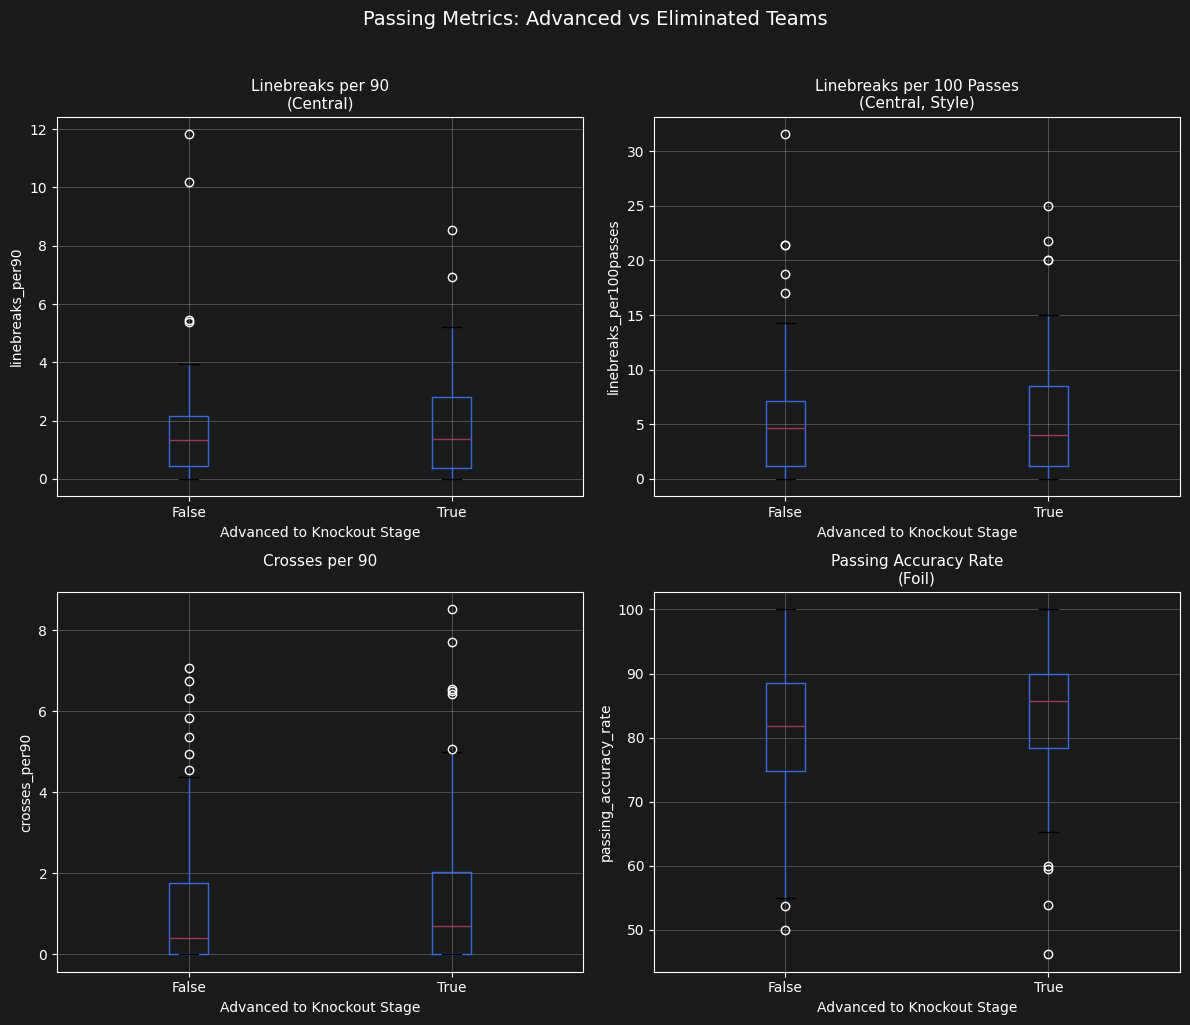

In [191]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

metrics = [
    ('linebreaks_per90', 'Linebreaks per 90\n(Central)'),
    ('linebreaks_per100passes', 'Linebreaks per 100 Passes\n(Central, Style)'),
    ('crosses_per90', 'Crosses per 90\n'),
    ('passing_accuracy_rate', 'Passing Accuracy Rate\n(Foil)')
]

for ax, (col, title) in zip(axes.flat, metrics):
    sample_df.boxplot(column=col, by='advanced', ax=ax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Advanced to Knockout Stage')
    ax.set_ylabel(col)

plt.suptitle('')
fig.suptitle('Passing Metrics: Advanced vs Eliminated Teams', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('all_metrics_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

Outliers remain visible even after the data was thresolded (>5 passes, >20 mins). These remaining outliers were investigated while filtering. Some are low volume players where a small denominator make the ratio unstable and some are genuine high-volume performances distorted by extrapolating a short cameo to a full 90 minutes. In both cases, the values are real, correctly recorded data and are retained and disclosed as limitation. This right-skew is why both mean and median are reported throughout.